<a href="https://colab.research.google.com/github/sagasucksatlife1/QuantProjects/blob/main/CreditRiskModeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Credit Risk Modeling***

This projects was aimed at creating a code of risk analyisis that banks use to select and crop the loan application, by implementing differneting technique and varibale to crop the following. PD (probablity of default), LDG (loss given default), EAD (exposure at default).



In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

here we are taking a default dataset with with 45000 differnt loan appliction and total of 14 different parameters 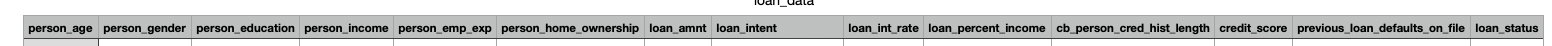

In [23]:
loan_data = pd.read_csv("/content/loan_data.csv")
loan_data.head(10)
loan_data.shape


(45000, 14)

In [24]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
loan_data["person_gender"] = le.fit_transform(loan_data["person_gender"])
loan_data["person_education"] = le.fit_transform(loan_data["person_education"])
loan_data["person_home_ownership"] = le.fit_transform(loan_data["person_home_ownership"])
loan_data["loan_intent"] = le.fit_transform(loan_data["loan_intent"])
loan_data["previous_loan_defaults_on_file"] = le.fit_transform(loan_data["previous_loan_defaults_on_file"])
print(le.classes_)
loan_data.head()

['No' 'Yes']


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,0,4,71948.0,0,3,35000.0,4,16.02,0.49,3.0,561,0,1
1,21.0,0,3,12282.0,0,2,1000.0,1,11.14,0.08,2.0,504,1,0
2,25.0,0,3,12438.0,3,0,5500.0,3,12.87,0.44,3.0,635,0,1
3,23.0,0,1,79753.0,0,3,35000.0,3,15.23,0.44,2.0,675,0,1
4,24.0,1,4,66135.0,1,3,35000.0,3,14.27,0.53,4.0,586,0,1


Some of the data was inn string format and since the model wont be able to recognise it thus we convert them into numeric through encoding. person gender, person eduction,person home ownership,loan intent,previous_loan_defaults_on_file, we use the label_encoding fuction to encode the following data, and then finalliy after the conversion we present the final data.

In [25]:
x = loan_data.drop("loan_status",axis=1)
y = loan_data["loan_status"]


we seperate the dataset into two different dataset x and y , x contains training vraibles and y contains target varibales.

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score,f1_score,recall_score,precision_score
x_train,x_test, y_train,y_test= train_test_split(x,y, test_size=0.2, random_state= 42)

lg = LogisticRegression(class_weight='balanced')
lg.fit(x_train,y_train)
PD = lg.predict_proba(x_test)[:, 1]
threshold = 0.3
y_pred = (PD > threshold).astype(int)

accuracy = accuracy_score(y_test,y_pred)
roc_auc = roc_auc_score(y_test,PD)
f1 = f1_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
print("Accuracy:",accuracy)
print("ROC AUC:",roc_auc)
print("F1 Score:",f1)
print("Recall:",recall)
print("Precision:",precision)
print("PD:",PD)


Accuracy: 0.6395555555555555
ROC AUC: 0.8536704887579271
F1 Score: 0.5272515301661324
Recall: 0.9
Precision: 0.372835943940643
PD: [0.08678144 0.75961072 0.83632071 ... 0.75811351 0.72765918 0.5775048 ]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


we use logistic regression model on the data and train it to predict the default pobabilties (PD), Probability of Default (PD) is the likelihood that a borrower will fail to meet their debt obligations within a specified time horizon (usually 1 year).

first time when we run the data,we experience imbalanced calsses that meant some class were given more importance then the others creating false results. thus we used weight_class = balance to balance all the calsses, we get the folowoing results from the following datasets when tarined...

Accuracy: 0.6395555555555555

ROC AUC: 0.8536704887579271\

F1 Score: 0.5272515301661324

Recall: 0.9

Precision: 0.372835943940643
 then we use this PD = lg.predict_proba(x_test)[:, 1] function to genefrate actual probabilites rather than the final soultion.

In [27]:
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb = XGBClassifier(scale_pos_weight=scale_pos_weight)
calibrated = CalibratedClassifierCV(xgb, method='sigmoid')
calibrated.fit(x_train, y_train)
y_pred_xgb = calibrated.predict(x_test)
PD_XGB = calibrated.predict_proba(x_test)[:, 1]
PD_train = calibrated.predict_proba(x_train)[:, 1]

accuracy = accuracy_score(y_test,y_pred_xgb)
roc_auc = roc_auc_score(y_test,PD_XGB)
f1 = f1_score(y_test,y_pred_xgb)
recall = recall_score(y_test,y_pred_xgb)
precision = precision_score(y_test,y_pred_xgb)

print("Accuracy_XGB:",accuracy)
print("ROC AUC_XGB:",roc_auc)
print("F1 Score_XGB:",f1)
print("Recall_XGB:",recall)
print("Precision_XGB:",precision)


def assign_grade(pd):
    if pd < 0.05:
        return "A"
    elif pd < 0.1:
        return "B"
    elif pd < 0.2:
        return "C"
    elif pd < 0.4:
        return "D"
    else:
        return "E"

y_test_df = pd.DataFrame(y_test)
y_test_df["PD_XGB"] = PD_XGB
y_test_df["Risk_Grade"] = y_test_df["PD_XGB"].apply(assign_grade)
train_df = pd.DataFrame(y_train)
train_df["PD_XGB"] = PD_train
train_df["Risk_Grade"] = train_df["PD_XGB"].apply(assign_grade)

train_data = pd.merge(x_train, train_df, left_index=True, right_index=True)
data = pd.merge(x_test,y_test_df,left_index=True,right_index=True)
final_data = pd.concat([train_data, data])
final_data = final_data.sort_index()
final_data["PD_XGB"] = final_data["PD_XGB"].clip(0.01, 0.6)

final_data.head()



Accuracy_XGB: 0.9337777777777778
ROC AUC_XGB: 0.9791010612175175
F1 Score_XGB: 0.8500251635631605
Recall_XGB: 0.8402985074626865
Precision_XGB: 0.859979633401222


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,PD_XGB,Risk_Grade
0,22.0,0,4,71948.0,0,3,35000.0,4,16.02,0.49,3.0,561,0,1,0.600000,E
1,21.0,0,3,12282.0,0,2,1000.0,1,11.14,0.08,2.0,504,1,0,0.011021,A
2,25.0,0,3,12438.0,3,0,5500.0,3,12.87,0.44,3.0,635,0,1,0.600000,E
3,23.0,0,1,79753.0,0,3,35000.0,3,15.23,0.44,2.0,675,0,1,0.600000,E
4,24.0,1,4,66135.0,1,3,35000.0,3,14.27,0.53,4.0,586,0,1,0.600000,E


after the bad results of the logistic regression we use XG boost to perdict the variable, as we run the XG boost everytrhing was 99% that meant overconfident model, as the probablities it gave were all extreme 0,1 so we used y_pred_xgb = calibrated.predict(x_test), and this giv ed a smooth s cuvre (Sigmiod function) so less confident and less extremist model,


we assinned grades of probablity of defalt rating these loan application based on if they held a risk of default.
**MAJOR PRBOLEM**- we add the these data in the test dataset that is only 80% of the actual data if we contued we will not be able to precit the 80% of the data.

solution we predict all the data train as well as test , we merge the x test and y test and y traina and y train and at last we merge all of them, to create tyhe final dataset,
XG boost was abe to predict the pattern with exterme percision

Accuracy_XGB: 0.9337777777777778

ROC AUC_XGB: 0.9791010612175175

F1 Score_XGB: 0.8500251635631605

Recall_XGB: 0.8402985074626865

Precision_XGB: 0.859979633401222

In [29]:
final_data["EAD"]  = final_data["loan_amnt"]
final_data.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,PD_XGB,Risk_Grade,LGD,EAD
0,22.0,0,4,71948.0,0,3,35000.0,4,16.02,0.49,3.0,561,0,1,0.600000,E,0.4,35000.0
1,21.0,0,3,12282.0,0,2,1000.0,1,11.14,0.08,2.0,504,1,0,0.011021,A,0.6,1000.0
2,25.0,0,3,12438.0,3,0,5500.0,3,12.87,0.44,3.0,635,0,1,0.600000,E,0.2,5500.0
3,23.0,0,1,79753.0,0,3,35000.0,3,15.23,0.44,2.0,675,0,1,0.600000,E,0.2,35000.0
4,24.0,1,4,66135.0,1,3,35000.0,3,14.27,0.53,4.0,586,0,1,0.600000,E,0.6,35000.0


Exposure at Default (EAD) is the total amount a lender is exposed to at the moment a borrower defaults.
we also calculate the Exposure at Default (EAD) since we have knowlege of no other dsamage we condoser the ead as the total loan amount.

In [28]:
def lgd(row):
  base = 0.4
  if row["person_home_ownership"] == 2:
    base = base - 0.2
  if row["loan_percent_income"] > 0.5:
    base = base + 0.2
  if row["previous_loan_defaults_on_file"] > 0:
    base = base + 0.4
  if row["loan_intent"] == [1, 5]:
    base = base - 0.3
  if row["loan_intent"] == [0,2,3,4]:
    base = base + 0.2
  if row["credit_score"] > 600:
    base = base - 0.2
  if row["credit_score"] < 400:
    base = base + 0.1


  return (min(max(base,0),1))

final_data = final_data.assign(LGD = final_data.apply(lgd,axis=1))
final_data["LGD"] = final_data["LGD"].clip(0.2, 0.6)



Loss Given Default (LGD) is the proportion of the exposure that is lost after a borrower defaults, considering any recoveries.since we dont have estimation of any reoverry value, we make a function take a base value and using the useful data like loan intent, previous delfuats, home ownership, and credit score.
we take the minimum value of all the data,
make a final dataset and add it all the value and add it into LGD.

In [30]:
final_data["expected_loss"] = final_data["EAD"]* final_data["PD_XGB"]* final_data["LGD"]
final_data.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,PD_XGB,Risk_Grade,LGD,EAD,expected_loss
0,22.0,0,4,71948.0,0,3,35000.0,4,16.02,0.49,3.0,561,0,1,0.600000,E,0.4,35000.0,8400.00000
1,21.0,0,3,12282.0,0,2,1000.0,1,11.14,0.08,2.0,504,1,0,0.011021,A,0.6,1000.0,6.61236
2,25.0,0,3,12438.0,3,0,5500.0,3,12.87,0.44,3.0,635,0,1,0.600000,E,0.2,5500.0,660.00000
3,23.0,0,1,79753.0,0,3,35000.0,3,15.23,0.44,2.0,675,0,1,0.600000,E,0.2,35000.0,4200.00000
4,24.0,1,4,66135.0,1,3,35000.0,3,14.27,0.53,4.0,586,0,1,0.600000,E,0.6,35000.0,12600.00000


Expected Loss (EL) is the average or anticipated loss a lender expects from a borrower or portfolio due to default over a given time horizon.

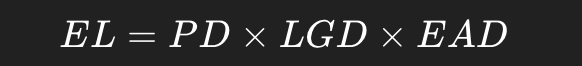

we add the final values in the dataset so that we can now go ahead and use these precit the poeple we need to give credit approval and the chnage it brings to the perfomance of KARTIK"S BANKS FOR BOYS :)

In [31]:
def risk_weight(row):
    pd = row["PD_XGB"]

    if pd < 0.01:
        return 0.2
    elif pd < 0.05:
        return 0.3
    elif pd < 0.1:
        return 0.5
    elif pd < 0.3:
        return 0.7
    elif pd < 0.6:
        return 0.9
    else:
        return 1.2
final_data = final_data.assign(risk_weight = final_data.apply(risk_weight,axis=1))
final_data.head(20)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,PD_XGB,Risk_Grade,LGD,EAD,expected_loss,risk_weight
0,22.0,0,4,71948.0,0,3,35000.0,4,16.02,0.49,3.0,561,0,1,0.600000,E,0.4,35000.0,8400.000000,1.2
1,21.0,0,3,12282.0,0,2,1000.0,1,11.14,0.08,2.0,504,1,0,0.011021,A,0.6,1000.0,6.612360,0.3
2,25.0,0,3,12438.0,3,0,5500.0,3,12.87,0.44,3.0,635,0,1,0.600000,E,0.2,5500.0,660.000000,1.2
3,23.0,0,1,79753.0,0,3,35000.0,3,15.23,0.44,2.0,675,0,1,0.600000,E,0.2,35000.0,4200.000000,1.2
4,24.0,1,4,66135.0,1,3,35000.0,3,14.27,0.53,4.0,586,0,1,0.600000,E,0.6,35000.0,12600.000000,1.2
5,21.0,0,3,12951.0,0,2,2500.0,5,7.14,0.19,2.0,532,0,1,0.600000,E,0.2,2500.0,300.000000,1.2
6,26.0,0,1,93471.0,1,3,35000.0,1,12.42,0.37,3.0,701,0,1,0.600000,E,0.2,35000.0,4200.000000,1.2
7,24.0,0,3,95550.0,5,3,35000.0,3,11.11,0.37,4.0,585,0,1,0.600000,E,0.4,35000.0,8400.000000,1.2
8,24.0,0,0,100684.0,3,3,35000.0,4,8.90,0.35,2.0,544,0,1,0.600000,E,0.4,35000.0,8400.000000,1.2
9,21.0,0,3,12739.0,0,2,1600.0,5,14.74,0.13,3.0,640,0,1,0.600000,E,0.2,1600.0,192.000000,1.2


we also create a functions called Risk Weight (RW) which is a factor assigned to an asset that reflects its level of credit risk, used to determine how much capital a bank must hold against that asset and add it to final dataset.

**now we compare the perfomace of the bakns between the defaluts bakns without a risk approval system and the one with this top of the line, top of my mind model, thank u**

In [32]:
final_data["Risk_Weighted_Asset"]= final_data["EAD"] * final_data["risk_weight"]
final_data["capital_requirement"] = final_data["Risk_Weighted_Asset"] * 0.105
final_data.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,...,previous_loan_defaults_on_file,loan_status,PD_XGB,Risk_Grade,LGD,EAD,expected_loss,risk_weight,Risk_Weighted_Asset,capital_requirement
0,22.0,0,4,71948.0,0,3,35000.0,4,16.02,0.49,...,0,1,0.600000,E,0.4,35000.0,8400.00000,1.2,42000.0,4410.0
1,21.0,0,3,12282.0,0,2,1000.0,1,11.14,0.08,...,1,0,0.011021,A,0.6,1000.0,6.61236,0.3,300.0,31.5
2,25.0,0,3,12438.0,3,0,5500.0,3,12.87,0.44,...,0,1,0.600000,E,0.2,5500.0,660.00000,1.2,6600.0,693.0
3,23.0,0,1,79753.0,0,3,35000.0,3,15.23,0.44,...,0,1,0.600000,E,0.2,35000.0,4200.00000,1.2,42000.0,4410.0
4,24.0,1,4,66135.0,1,3,35000.0,3,14.27,0.53,...,0,1,0.600000,E,0.6,35000.0,12600.00000,1.2,42000.0,4410.0


Total Risk-Weighted Assets (RWA) is the sum of all exposures adjusted by their respective risk weights, representing the total risk in the portfolio.

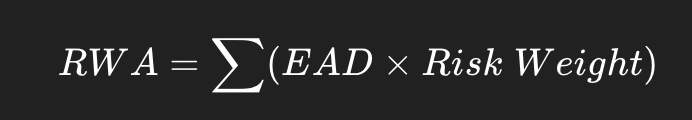

Total Capital Requirement is the total amount of capital a bank must hold to cover potential losses, based on regulatory standards.

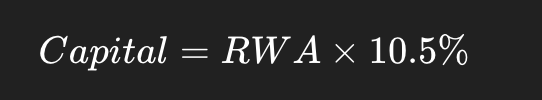

Capital Ratio is the proportion of capital held relative to total risk-weighted assets.

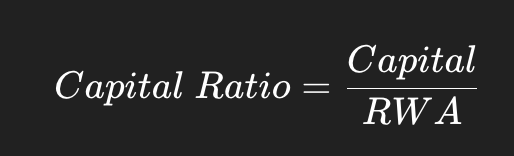

In [33]:
total_rwa = final_data["Risk_Weighted_Asset"].sum()
total_capital = final_data["capital_requirement"].sum()
capital_ratio = total_capital / total_rwa
final_data["EL"] = final_data["PD_XGB"] * final_data["LGD"] * final_data["EAD"]
total_el = final_data["EL"].sum()
total_capital_el_ratio = total_capital / total_el
print("Total Risk Weighted Asset:", total_rwa)
print("Total Capital Requirement:", total_capital)
print("Capital Ratio:", capital_ratio)
print("Total Expected Loss:", total_el)
print("Capital / EL ratio:", total_capital / total_el)


Total Risk Weighted Asset: 244897300.8
Total Capital Requirement: 25714216.584
Capital Ratio: 0.105
Total Expected Loss: 20199367.06479546
Capital / EL ratio: 1.2730209071162488


The portfolio has total risk of about ₹244.9 million, and the bank needs to keep around ₹25.7 million as a safety buffer, which matches the required 10.5% rule. The expected loss is about ₹20.2 million, meaning this is the average amount the bank could lose from these loans. Since the capital is only slightly higher than the expected loss (ratio ≈ 1.27), the bank can handle normal losses but doesn’t have a very strong cushion. In simple terms, the portfolio is stable but still a bit risky and could be improved by reducing high-risk loans.

In [38]:
def remove_defaulter(final_data):
  defaulters = final_data.sort_values(by="EL", ascending=False).head(int(len(final_data)*.20))
  final_data = final_data[~final_data.index.isin(defaulters.index)]
  return final_data

filtered_data = remove_defaulter(final_data)
filtered_total_capital = filtered_data["capital_requirement"].sum()
filtered_total_el = filtered_data["EL"].sum()
filtered_total_rwa = filtered_data["Risk_Weighted_Asset"].sum()
filtered_total_capital = filtered_data["capital_requirement"].sum()
filtered_capital_ratio = filtered_total_capital / filtered_total_rwa
filtered_capital_el_ratio = filtered_total_capital / filtered_total_el
print("New Capital / EL:", filtered_total_capital / filtered_total_el)
print("New Capital Ratio:", filtered_total_capital / filtered_total_rwa)
print("New Total Risk Weighted Asset:", filtered_total_rwa)
print("New Total Capital Requirement:", filtered_total_capital)
print("New Capital Ratio:", filtered_capital_ratio)
print("New Total Expected Loss:", filtered_total_el)


New Capital / EL: 3.2442290661898596
New Capital Ratio: 0.10500000000000001
New Total Risk Weighted Asset: 111293345.8
New Total Capital Requirement: 11685801.309
New Capital Ratio: 0.10500000000000001
New Total Expected Loss: 3602027.1906151897


After removing the high-risk borrowers, the portfolio improves significantly. The total risk (RWA) drops from about ₹244.9M to ₹111.3M, and the required capital also decreases from ₹25.7M to ₹11.7M, while still maintaining the same 10.5% capital ratio. More importantly, the expected loss falls sharply from ₹20.2M to about ₹3.6M, which is a huge reduction. As a result, the capital-to-expected loss ratio increases from 1.27 to 3.24, showing that the bank now has a much stronger buffer against losses. In simple terms, the portfolio becomes much safer and more stable after removing the riskiest loans.

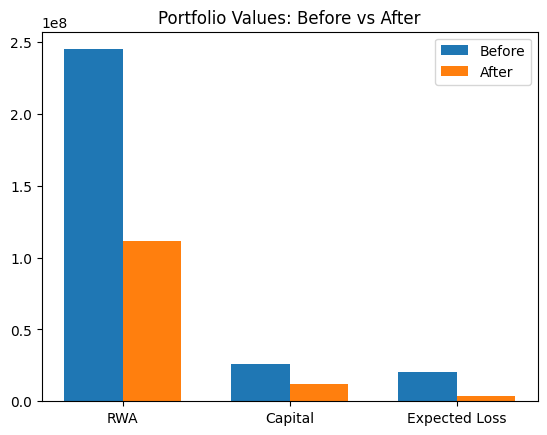

In [35]:
labels = ["RWA", "Capital", "Expected Loss"]

before = [total_rwa, total_capital, total_el]
after = [filtered_total_rwa, filtered_total_capital, filtered_total_el]

x = np.arange(len(labels))
width = 0.35

plt.figure()

plt.bar(x - width/2, before, width, label="Before")
plt.bar(x + width/2, after, width, label="After")

plt.xticks(x, labels)
plt.title("Portfolio Values: Before vs After")
plt.legend()

plt.show()

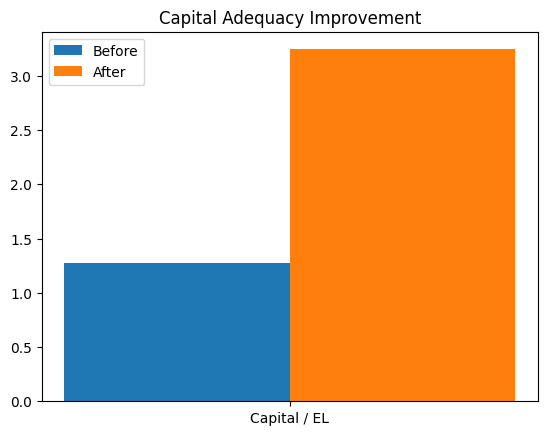

In [36]:
labels = ["Capital / EL"]

before = [total_capital_el_ratio]
after = [filtered_capital_el_ratio]

x = np.arange(len(labels))
width = 0.35

plt.figure()

plt.bar(x - width/2, before, width, label="Before")
plt.bar(x + width/2, after, width, label="After")

plt.xticks(x, labels)
plt.title("Capital Adequacy Improvement")
plt.legend()

plt.show()